In [23]:
# --- Core libraries ---
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import geopandas as gpd
from shapely.geometry import Point
import plotly.express as px # for interactive plots

# --- Scikit-learn: model training, preprocessing, CV, evaluation ---
from sklearn.model_selection import (
    GroupKFold,
    RandomizedSearchCV,
    cross_validate,
    train_test_split,
    GridSearchCV
)
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    balanced_accuracy_score,
    roc_auc_score,
    make_scorer,
    ConfusionMatrixDisplay
)
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.cluster import MiniBatchKMeans
from sklearn.preprocessing import LabelEncoder
from sklearn.neighbors import BallTree


# --- XGBoost ---
from xgboost import XGBRegressor, plot_tree, plot_importance
import xgboost  # Optional: useful for checking version

# --- Other ---
from haversine import haversine
import scipy.stats as stats
import gstools as gs #variogram modeling
from sklearn.metrics import pairwise_distances # for distance calculations
from scipy.cluster.hierarchy import linkage, dendrogram #for hierarchical clustering dendrogram
from tabulate import tabulate # for pretty printing tables
from scipy.spatial.distance import squareform

#--- Custom Functions as defined by the user ---
import sys
sys.path.append(os.path.abspath("tools"))
import functions

In [24]:
print("Current working directory:", os.getcwd())

#load in 
df_raw = pd.read_csv("../../../data/finaldatasets/testdata/finalfr/finalfrfr/unjittered_eng.csv")  # for variogram, etc.
df_final = df_raw.copy()  # working copy for feature engineering + model prep

Current working directory: /home/sebastian-dohne/Documents/FinalProject/code/analysis/kagglefeatureengineering


/tmp/ipykernel_61008/3818711570.py:4: DtypeWarning: Columns (14,15,16,17,20,22,23,24,26,28,29,30,31,32,39,40,42,43,47,48,49) have mixed types. Specify dtype option on import or set low_memory=False.
  df_raw = pd.read_csv("../../../data/finaldatasets/testdata/finalfr/finalfrfr/unjittered_eng.csv")  # for variogram, etc.


Data summary function

In [25]:
functions.summarize_dataframe(df_final)

| variable                                              | dtype   |   count |   pct_complete |   n_unique |
|-------------------------------------------------------|---------|---------|----------------|------------|
| id                                                    | int64   |   22709 |          100   |      22315 |
| Trans3                                                | float64 |   22709 |          100   |        528 |
| Trans1                                                | float64 |   22709 |          100   |        536 |
| EvapS9                                                | float64 |   22709 |          100   |        544 |
| EvapS8                                                | float64 |   22709 |          100   |        544 |
| EvapS7                                                | float64 |   22709 |          100   |        542 |
| EvapS6                                                | float64 |   22709 |          100   |        529 |
| EvapS5                    

#### Drop location defined cols

For non-engineered features, see below

In [26]:
# Define groups of columns to drop
LOCATION_COLS = [
    "id", "Data.ID", "Location", "State.Region.County.Province", "Country", "Continent",
    "Latitude..N.S.", "Longitude..E.W.", "group", "Location.source", "Conversion.for.latitude", "Conversion.for.longitude",
    "start_date", "end_date", "sowing_year", "year",
    "Location.source", "Observation.period", "X", "Y", "unit_code", "Year_x", 
    "latitude_jittered","longitude_jittered", "jitter_radius_km", "group_id"
]

# "Conversion.for.latitude", "Conversion.for.longitude"
HIGH_CARDINALITY_COLS = [
    "Treatment.type", "Emissions..yes.no.",
    "Irrigation..mm.", "Harvesting.date.1","Pest.severity.score.......66",
    "Agricultural_Use_–_Other_Pesticides_nes_(t)","Agricultural_Use_._Rodenticides_.t.", 
    "irr_end_date", "end_date", "rainfed_end_date"
]


COLLINEAR_COLS = [
    "harvest_month", "harvest_date_clean", "harvest_week", "dryspells.5days.",
    "Planting.date", "Planting_Month", "Planting.date.1", "Planting_Week"
]

# These columns are used for testing purposes
TESTCOLUMNS = [
    "gdp", "hdi", "irr_start_date", "Crop.variety",
    "rainfed_start_date", "drydays.annualsum.", "harvest_dayofyear", ""
    "Mean.annual.precipitation..mm.", "irrigation_applied", "Sand", 
    "Irrigation.mm_clean", "Mean.annual.temperature..Â.C.", "Irrigation.mm_clean", "Wheat.Type", 
]

# Combine all columns to drop into a single set (to avoid duplicates)
COLUMNS_TO_DROP = set(LOCATION_COLS + HIGH_CARDINALITY_COLS + COLLINEAR_COLS + TESTCOLUMNS)

# Drop all listed columns if they exist in the DataFrame
df_final = df_raw.drop(columns=[col for col in COLUMNS_TO_DROP if col in df_raw.columns])

# Optional: Review dropped and remaining columns
print("Original shape:", df_raw.shape)
print("Shape after dropping:", df_final.shape)
print("Dropped columns:", [col for col in COLUMNS_TO_DROP if col in df_raw.columns])
print("Remaining columns:", df_final.columns.tolist())

# Drop columns with less than 20% completeness
df_final = df_final.loc[:, df_final.count() / len(df_final) >= 0.2]

# Drop unnamed columns and rows with NaN in the target variable
df_final = df_final.loc[:, ~df_final.columns.str.contains('^Unnamed')]
df_final = df_final.dropna(subset=["Grain.yield..tons.ha.1."])


Original shape: (22709, 180)
Shape after dropping: (22709, 133)
Dropped columns: ['Harvesting.date.1', 'Irrigation..mm.', 'end_date', 'irr_start_date', 'sowing_year', 'Planting.date.1', 'State.Region.County.Province', 'jitter_radius_km', 'Pest.severity.score.......66', 'harvest_month', 'Conversion.for.latitude', 'start_date', 'Sand', 'Mean.annual.temperature..Â.C.', 'Planting_Month', 'harvest_date_clean', 'harvest_week', 'longitude_jittered', 'Treatment.type', 'Agricultural_Use_._Rodenticides_.t.', 'irr_end_date', 'rainfed_start_date', 'Longitude..E.W.', 'Latitude..N.S.', 'Observation.period', 'rainfed_end_date', 'Planting.date', 'Wheat.Type', 'Planting_Week', 'group_id', 'Crop.variety', 'id', 'latitude_jittered', 'Data.ID', 'Irrigation.mm_clean', 'Emissions..yes.no.', 'Mean.annual.precipitation..mm.', 'harvest_dayofyear', 'Location', 'Continent', 'Conversion.for.longitude', 'hdi', 'irrigation_applied', 'Location.source', 'Country', 'gdp', 'year']
Remaining columns: ['Tillage.type', 'T

In [27]:
df_final = df_final.loc[:, df_final.notna().mean() >= 0.5]

In [28]:
functions.summarize_dataframe(df_final)

| variable                                              | dtype   |   count |   pct_complete |   n_unique |
|-------------------------------------------------------|---------|---------|----------------|------------|
| Grain.yield..tons.ha.1.                               | float64 |   22709 |          100   |       9460 |
| EvapS4                                                | float64 |   22709 |          100   |        537 |
| temp2                                                 | float64 |   22709 |          100   |        263 |
| temp1                                                 | float64 |   22709 |          100   |        264 |
| pr_irrigated                                          | float64 |   22709 |          100   |        181 |
| AEZ                                                   | int64   |   22709 |          100   |         26 |
| Elevation                                             | int64   |   22709 |          100   |        191 |
| Trans9                    

In [29]:
float_cols = df_final.select_dtypes(include=['float64', 'float32', 'int64', 'int32'])

functions.summarize_dataframe(float_cols)

| variable                                              | dtype   |   count |   pct_complete |   n_unique |
|-------------------------------------------------------|---------|---------|----------------|------------|
| Grain.yield..tons.ha.1.                               | float64 |   22709 |          100   |       9460 |
| Trans7                                                | float64 |   22709 |          100   |        529 |
| temp2                                                 | float64 |   22709 |          100   |        263 |
| temp1                                                 | float64 |   22709 |          100   |        264 |
| pr_irrigated                                          | float64 |   22709 |          100   |        181 |
| AEZ                                                   | int64   |   22709 |          100   |         26 |
| Elevation                                             | int64   |   22709 |          100   |        191 |
| Trans9                    

##### Check correlation between variables 

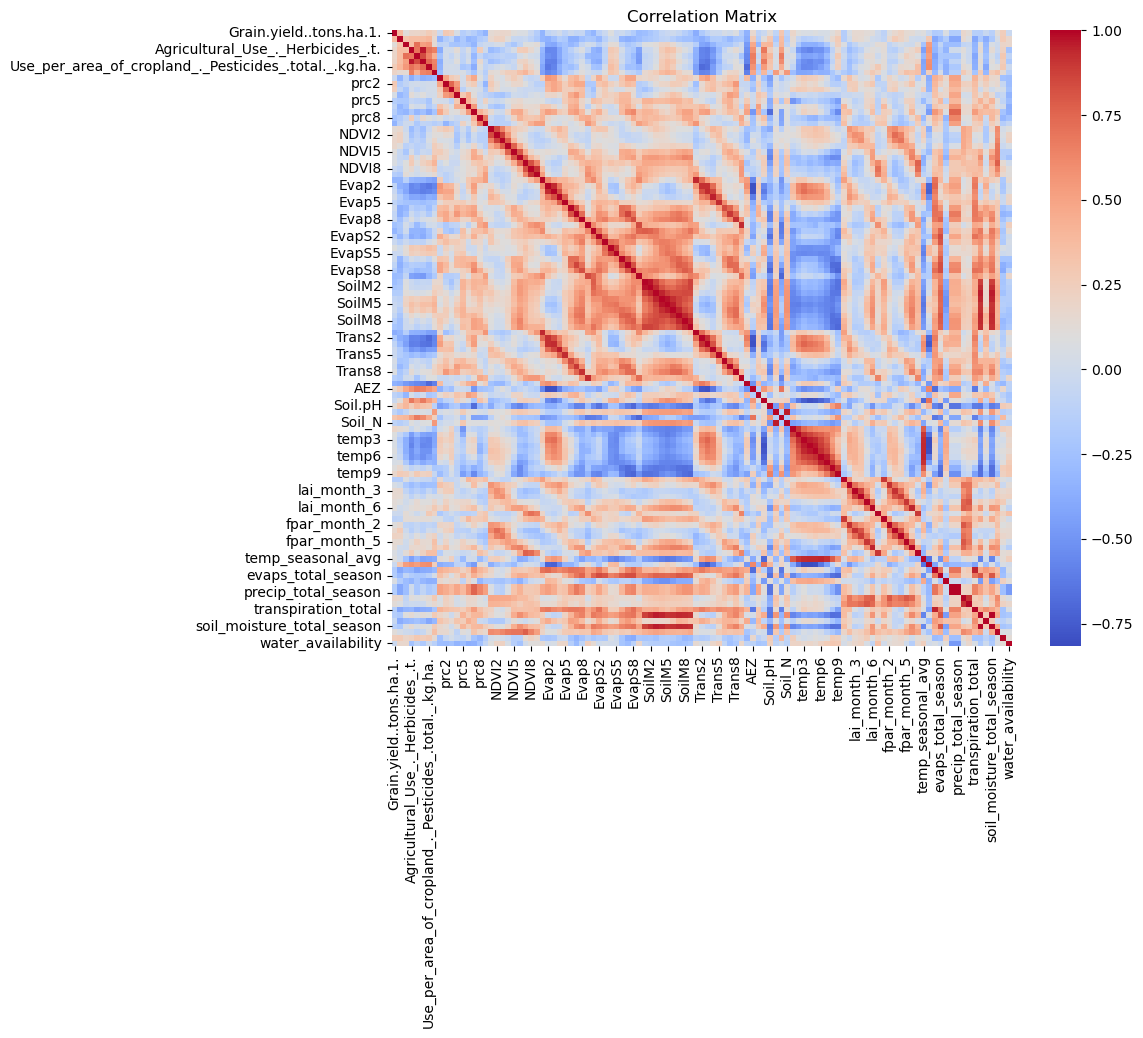

In [30]:
# Select only float columns for correlation
# Select only float columns excbept the target variable
corr_matrix = float_cols.corr(method='pearson')

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=False, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

##### Reduce multicollinearity by comparing correlation against itself and target variable 

In [31]:
def correlation_with_yield_priority(dataset, threshold, yield_column='Grain.yield..tons.ha.1.'):
    """
    Identifies highly correlated variable pairs and removes the one less correlated with yield.
    
    Parameters:
    dataset: pandas DataFrame
    threshold: float, correlation threshold (e.g., 0.8)
    yield_column: str, name of the yield column
    
    Returns:
    set: column names to remove (less correlated with yield)
    """
    col_to_remove = set()
    corr_matrix = dataset.corr()
    
    # Get correlations with yield for comparison
    yield_correlations = corr_matrix[yield_column].abs()
    
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            # Skip if one of the columns is the yield column itself
            col_i = corr_matrix.columns[i]
            col_j = corr_matrix.columns[j]
            
            if col_i == yield_column or col_j == yield_column:
                continue
                
            if abs(corr_matrix.iloc[i, j]) > threshold:
                # Compare correlations with yield
                corr_i_with_yield = yield_correlations[col_i]
                corr_j_with_yield = yield_correlations[col_j]
                
                # Remove the column less correlated with yield
                if corr_i_with_yield >= corr_j_with_yield:
                    col_to_remove.add(col_j)
                else:
                    col_to_remove.add(col_i)
    
    return col_to_remove


In [32]:
# Get set of correlated columns
correlated_cols = correlation_with_yield_priority(float_cols, 0.95, yield_column='Grain.yield..tons.ha.1.')

# Drop correlated columns from float_cols to get a DataFrame with only uncorrelated columns
uncorrelated_float_cols = float_cols.drop(columns=correlated_cols, errors='ignore')

Observe reduced correlation matrix

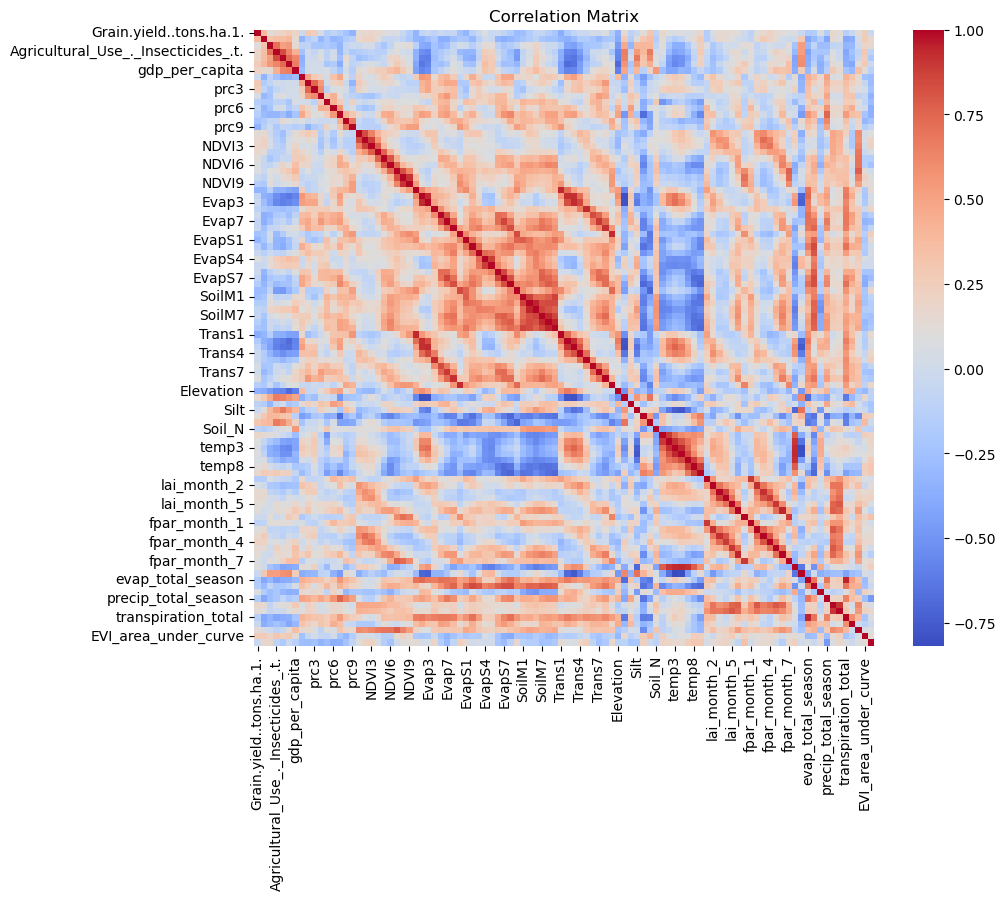

In [33]:
# Select only float columns for correlation
# Select only float columns except the target variable
corr_matrix = uncorrelated_float_cols.corr(method='pearson')

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=False, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

In [34]:
# 1. Check what's actually in your correlation matrix
print("Correlation matrix info:")
print(f"Shape: {corr_matrix.shape}")
print(f"Columns: {list(corr_matrix.columns)}")

Correlation matrix info:
Shape: (98, 98)
Columns: ['Grain.yield..tons.ha.1.', 'N.rate..kg.N.ha.1.', 'Agricultural_Use_._Fungicides_and_Bactericides_.t.', 'Agricultural_Use_._Insecticides_.t.', 'Agricultural_Use_._Pesticides_.total._.t.', 'Use_per_area_of_cropland_._Pesticides_.total._.kg.ha.', 'gdp_per_capita', 'prc1', 'prc2', 'prc3', 'prc4', 'prc5', 'prc6', 'prc7', 'prc8', 'prc9', 'NDVI1', 'NDVI2', 'NDVI3', 'NDVI4', 'NDVI5', 'NDVI6', 'NDVI7', 'NDVI8', 'NDVI9', 'Evap1', 'Evap2', 'Evap3', 'Evap5', 'Evap6', 'Evap7', 'Evap8', 'Evap9', 'EvapS1', 'EvapS2', 'EvapS3', 'EvapS4', 'EvapS5', 'EvapS6', 'EvapS7', 'EvapS8', 'EvapS9', 'SoilM1', 'SoilM3', 'SoilM4', 'SoilM7', 'SoilM8', 'SoilM9', 'Trans1', 'Trans2', 'Trans3', 'Trans4', 'Trans5', 'Trans6', 'Trans7', 'Trans8', 'Trans9', 'Elevation', 'AEZ', 'Clay', 'Silt', 'Soil.pH', 'pr_irrigated', 'Soil_N', 'temp1', 'temp2', 'temp3', 'temp5', 'temp7', 'temp8', 'temp9', 'lai_month_1', 'lai_month_2', 'lai_month_3', 'lai_month_4', 'lai_month_5', 'lai_month_

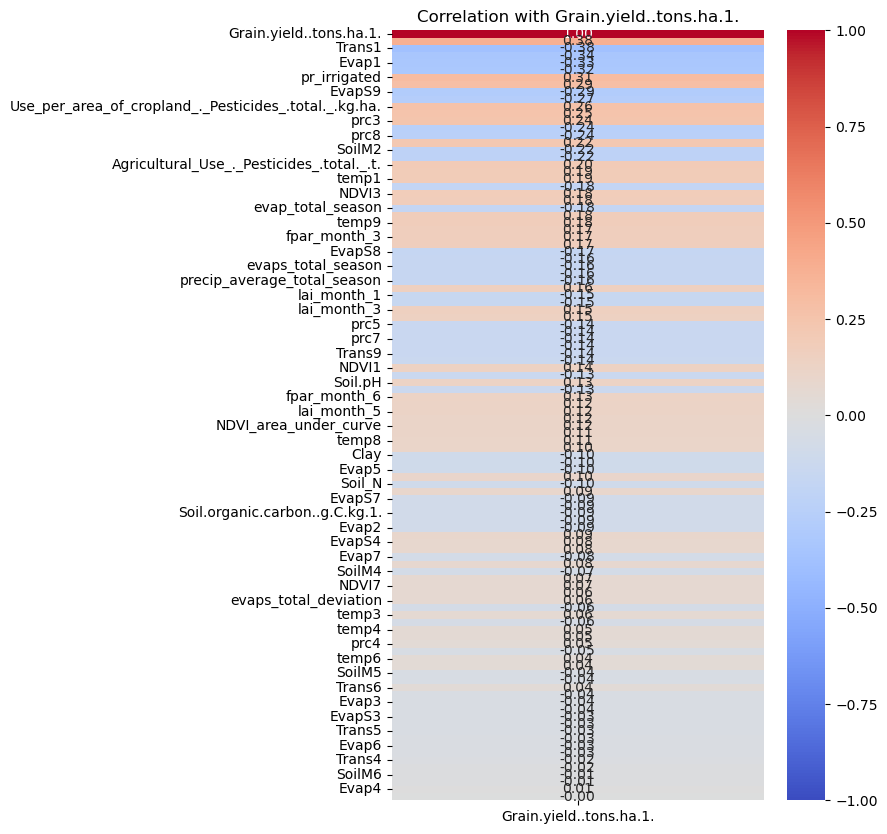

,Grain.yield..tons.ha.1.
Grain.yield..tons.ha.1.,1.000000
N.rate..kg.N.ha.1.,0.379546
Trans1,-0.376850
prc9,-0.337423
Evap1,-0.333326
...,...
EvapS6,-0.015047
SoilM6,-0.013875
lai_month_7,-0.012649
Evap4,0.006588


In [35]:
def plot_feature_correlations(df, target_col, method='pearson', sort_abs=True, figsize=(6, 10)):
    # Select numeric columns (float types)
    float_df = df.select_dtypes(include=['float32', 'float64'])
    
    if target_col not in float_df.columns:
        raise ValueError(f"Target column '{target_col}' is not numeric or not in DataFrame.")
    
    # Compute correlation matrix
    corr = float_df.corr(method=method)
    
    # Extract and sort correlation with target
    target_corr = corr[[target_col]]
    if sort_abs:
        target_corr = target_corr.reindex(target_corr[target_col].abs().sort_values(ascending=False).index)
    else:
        target_corr = target_corr.sort_values(by=target_col, ascending=False)
    
    # Plot
    plt.figure(figsize=figsize)
    sns.heatmap(target_corr, annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1)
    plt.title(f"Correlation with {target_col}")
    plt.show()
    
    return target_corr


plot_feature_correlations(df_final, "Grain.yield..tons.ha.1.")

### Observe correlation in dendrogram format 

In [36]:
def plot_correlation_dendrogram(df, linkage_method='complete'):
    """
    Creates a correlation dendrogram for float columns in a DataFrame.
    Does exactly the same processing as the original code.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        Input dataframe
    linkage_method : str, default='complete'
        Linkage method for hierarchical clustering ('complete', 'ward', 'average', 'single')
    """
    
    # Keep just the float columns
    float_cols = df.select_dtypes(include=['float64', 'float32'])
    
    # Remove columns with too many NaN values or constant values
    threshold = len(float_cols) * 0.5
    float_cols = float_cols.dropna(axis=1, thresh=threshold)
    float_cols = float_cols.loc[:, float_cols.var() > 0]
    float_cols = float_cols.dropna()
    
    print(f"After cleaning: {float_cols.shape}")
    
    # Compute absolute correlation matrix
    corr_matrix = float_cols.corr().abs()
    corr_matrix = corr_matrix.fillna(0)
    
    # Convert correlation to distance
    distance_matrix = 1 - corr_matrix
    
    # Clip distance values to [0, 1] to avoid negative values due to floating point errors
    distance_matrix = np.clip(distance_matrix, 0, 1)
    
    # Ensure diagonal is exactly zero
    np.fill_diagonal(distance_matrix.values, 0)
    
    # Check the diagonal is now zero
    print(f"Diagonal values: {np.diag(distance_matrix)[:5]}...")  # Show first 5
    
    # Convert to condensed distance matrix
    condensed_distance = squareform(distance_matrix)
    
    # Perform hierarchical clustering
    linked = linkage(condensed_distance, method=linkage_method)
    
    # Plot dendrogram
    plt.figure(figsize=(15, 8))
    dendrogram(linked, 
               labels=distance_matrix.columns, 
               leaf_rotation=90,
               leaf_font_size=8)
    plt.title(f"Dendrogram of Features Based on Correlation ({linkage_method.capitalize()} Linkage)", fontsize=14)
    plt.xlabel("Features", fontsize=12)
    plt.ylabel("Distance", fontsize=12)
    plt.tight_layout()
    plt.show()

After cleaning: (12859, 95)
Diagonal values: [0. 0. 0. 0. 0.]...


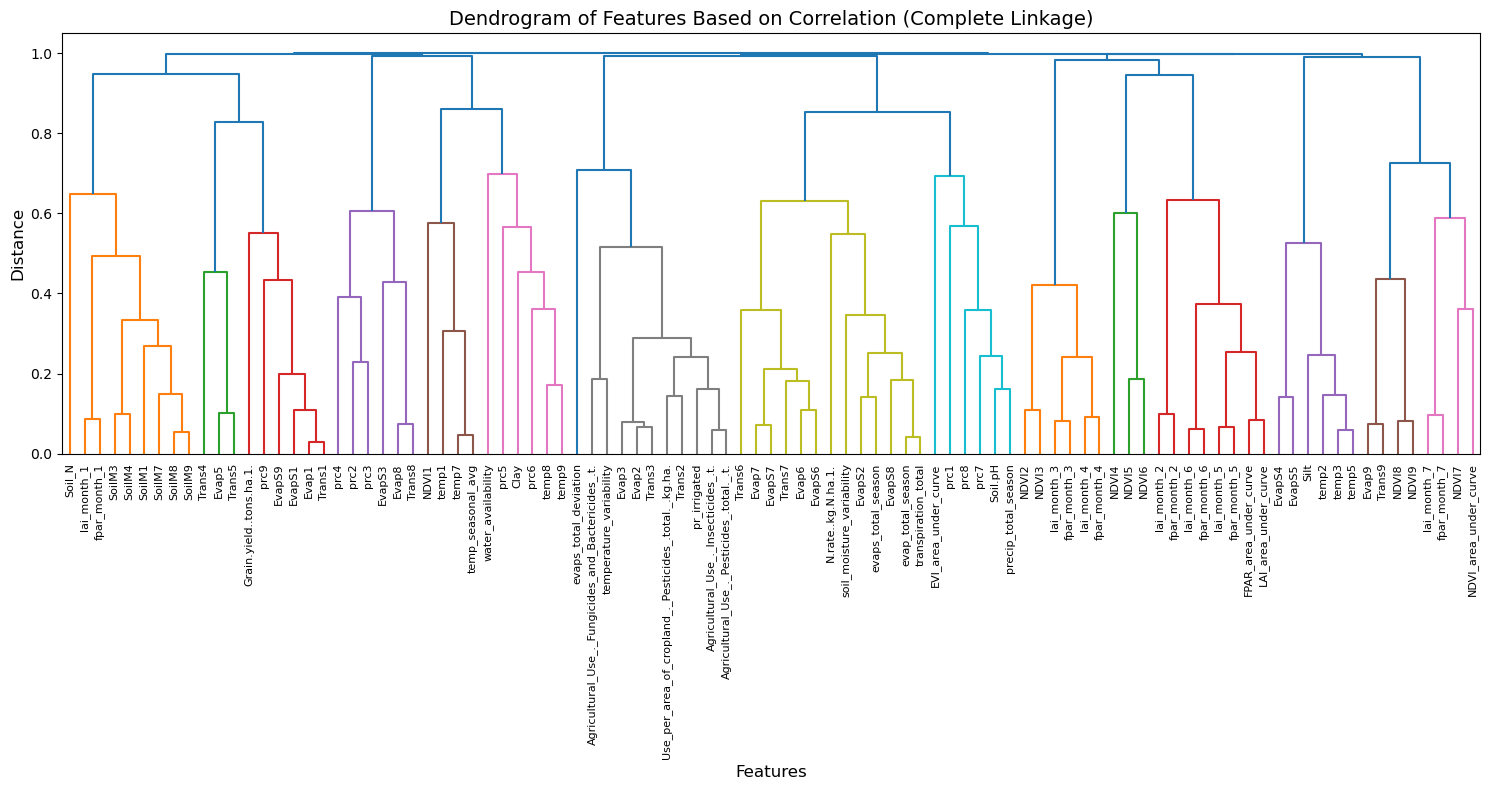

In [37]:
plot_correlation_dendrogram(uncorrelated_float_cols, linkage_method='complete')

Select uncorrelated vars and categorical features

In [38]:
Catcols = ['id', 'Conversion.for.longitude', 'Conversion.for.latitude', 'sowing_year', 'start_date', 'end_date', 'Country', 'Continent', 'Location', 'Observation.period', 
             "Crop.variety", "Treatment.type", "Pest.prescence....64", "Treatment_Category", "Tillage.type", "Soil.type" 
]

# Combine uncorrelated float columns and categorical columns
selected_cols = list(uncorrelated_float_cols.columns) + [col for col in Catcols if col in df_raw.columns]
df_final = df_raw[selected_cols]

In [39]:
functions.summarize_dataframe(df_final)

| variable                                              | dtype   |   count |   pct_complete |   n_unique |
|-------------------------------------------------------|---------|---------|----------------|------------|
| Grain.yield..tons.ha.1.                               | float64 |   22709 |          100   |       9460 |
| evap_total_season                                     | float64 |   22709 |          100   |        544 |
| temp_seasonal_avg                                     | float64 |   22709 |          100   |        303 |
| temp9                                                 | float64 |   22709 |          100   |        277 |
| temp8                                                 | float64 |   22709 |          100   |        277 |
| temp7                                                 | float64 |   22709 |          100   |        275 |
| temp5                                                 | float64 |   22709 |          100   |        275 |
| temp3                     

In [40]:
df_final.to_csv("../../../data/finaldatasets/testdata/finalfr/finalfrfr/unjittereduncorrelated.csv", index=False)